In [1]:
import pandas as pd
import numpy as np

prices = pd.read_csv(
    "../data/prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267078,136.742554,59.450500,88.292404,282.886383,131.293930,102.634377,30.269539,88.640495,106.224525,...,78.699928,56.421844,4.922529,72.280716,127.825645,110.094933,191.993881,107.888252,33.712955,28.800240
2018-01-03,40.260059,139.322906,60.209999,88.836777,283.801239,131.494537,103.499397,30.511000,89.286644,106.680595,...,79.066162,56.412956,5.246499,72.192986,128.338547,110.445290,194.007904,108.962334,33.020176,29.051458
2018-01-04,40.447075,138.735779,60.479500,90.314392,282.724426,133.300400,104.865761,30.597322,89.008736,106.633095,...,79.762054,56.377411,5.274156,72.703316,127.640266,110.445290,194.850021,109.367455,33.127251,29.077751
2018-01-05,40.907562,139.562393,61.457001,90.520370,294.322327,135.407333,106.261620,31.021097,88.862816,106.053505,...,80.750977,56.857292,5.318850,72.751152,130.285141,110.245094,198.565643,111.986710,33.051670,29.250097
2018-01-08,40.755630,139.523788,62.343498,89.687523,295.570770,138.810043,107.008705,31.342834,89.300545,104.533295,...,80.833328,57.363838,5.481823,73.133873,131.008133,109.652832,195.119171,112.438950,32.994991,29.682444


In [2]:
returns = prices.pct_change()

returns.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.018870,0.012775,0.006166,0.003234,0.001528,0.008428,0.007977,0.007290,0.004293,...,0.004654,-0.000158,0.065814,-0.001214,0.004013,0.003182,0.010490,0.009955,-0.020549,0.008723
2018-01-04,0.004645,-0.004214,0.004476,0.016633,-0.003794,0.013733,0.013202,0.002829,-0.003113,-0.000445,...,0.008801,-0.000630,0.005271,0.007069,-0.005441,0.000000,0.004341,0.003718,0.003243,0.000905
2018-01-05,0.011385,0.005958,0.016163,0.002281,0.041022,0.015806,0.013311,0.013850,-0.001639,-0.005435,...,0.012398,0.008512,0.008474,0.000658,0.020721,-0.001813,0.019069,0.023949,-0.002282,0.005927
2018-01-08,-0.003714,-0.000277,0.014425,-0.009201,0.004242,0.025129,0.007031,0.010372,0.004926,-0.014334,...,0.001020,0.008909,0.030641,0.005261,0.005549,-0.005372,-0.017357,0.004038,-0.001715,0.014781


In [5]:
month_ends = prices.resample("ME").last().index
portfolio_returns = []
portfolio_dates = []
month_ends[:5]

DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31'],
              dtype='datetime64[us]', name='Date', freq='ME')

In [25]:
portfolio_returns = []
portfolio_dates = []

for i in range(12, len(month_ends)-1):
    formation_date = month_ends[i]
    next_date = month_ends[i+1]

    # use prices up to the formation date to compute the formation momentum
    current_prices = prices.loc[:formation_date]
    momentum = current_prices.pct_change(252)
    latest_momentum = momentum.iloc[-1]

    # select top 5 by momentum
    top5 = (
        latest_momentum
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    # equal weights
    weights = np.repeat(1/5, 5)

    # holding period returns for selected tickers between formation_date and next_date (inclusive)
    holding_period = returns.loc[formation_date:next_date, top5]
    daily_portfolio_return = (holding_period * weights).sum(axis=1)

    # compound daily returns to get the holding period return
    monthly_portfolio_return = ((1 + daily_portfolio_return).prod() - 1)

    # store results
    portfolio_returns.append(monthly_portfolio_return)
    portfolio_dates.append(next_date)

# build a time series for the strategy returns
portfolio = pd.Series(portfolio_returns, index=portfolio_dates)

# quick view
portfolio.head()



2019-02-28    0.076045
2019-03-31    0.017181
2019-04-30    0.035743
2019-05-31   -0.033143
2019-06-30    0.054990
dtype: float64

In [28]:
# Display the portfolio performance summary
portfolio.describe()

count    71.000000
mean      0.019289
std       0.059180
min      -0.124776
25%      -0.020743
50%       0.018626
75%       0.055781
max       0.179434
dtype: float64

<Axes: title={'center': 'Momentum Strategy Returns'}>

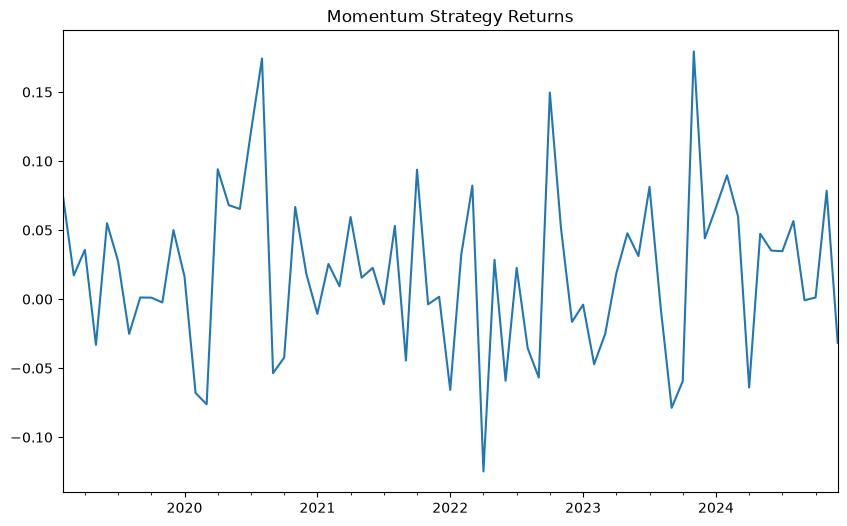

In [ ]:
# Plot the cumulative returns of the momentum strategy
portfolio.plot(title="Momentum Strategy Returns", figsize=(10, 6))

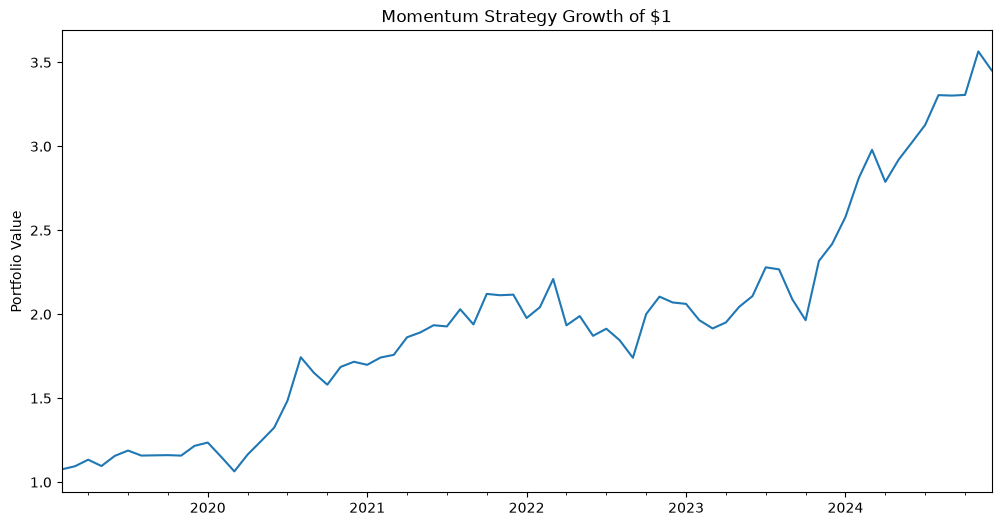

In [31]:
# Calculate the cumulative growth of the portfolio, starting at $1
portfolio_growth = (
    1 + portfolio
).cumprod()

import matplotlib.pyplot as plt
# Plot the cumulative growth of the portfolio
portfolio_growth.plot(
    figsize=(12,6)
)

plt.title(
    "Momentum Strategy Growth of $1"
)

plt.ylabel(
    "Portfolio Value"
)

plt.show()

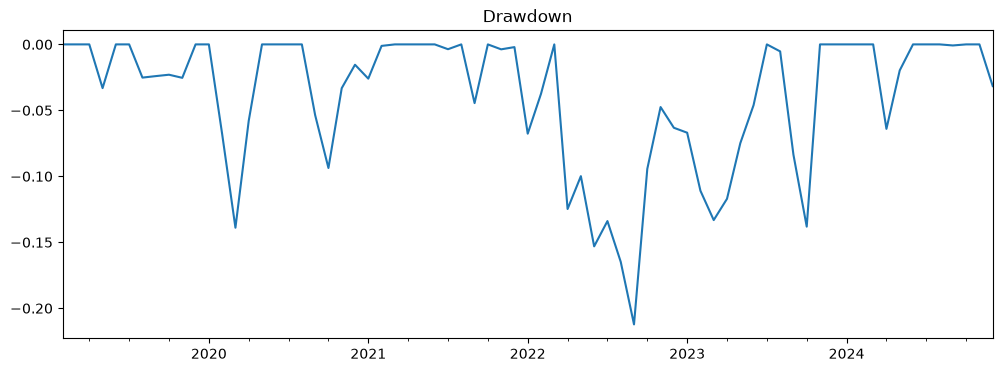

In [33]:
# Calculate the drawdown of the portfolio
running_max = portfolio_growth.cummax()

drawdown = (
    portfolio_growth
    - running_max
) / running_max

# Plot the drawdown of the portfolio
drawdown.plot(
    figsize=(12,4),
    title="Drawdown"
)

plt.show()

In [41]:
# Calculate the annualized return of the portfolio
annual_return = portfolio.mean() * 12

annual_return


np.float64(0.23146794612637123)

In [42]:
# Calculate the annualized volatility of the portfolio
annual_vol = portfolio.std() * np.sqrt(12)

annual_vol

np.float64(0.2050052261588503)

In [43]:
# Calculate the Sharpe ratio of the portfolio
sharpe = annual_return / annual_vol

sharpe

np.float64(1.1290831480901664)

In [45]:
# Calculate the maximum drawdown of the portfolio
max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.2122365734630091)

In [47]:
# Calculate the CAGR of the portfolio
years = (
    portfolio.index[-1]
    -
    portfolio.index[0]
).days / 365.25

cagr = (
    portfolio_growth.iloc[-1]
) ** (1/years) - 1

cagr

np.float64(0.23637401902739263)

In [50]:
# Display the performance metrics in a Performance Summary Table
metrics = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        cagr,
        annual_return,
        annual_vol,
        sharpe,
        max_drawdown
    ]
})

metrics

,Metric,Value
0,CAGR,0.236374
1,Annual Return,0.231468
2,Annual Volatility,0.205005
3,Sharpe Ratio,1.129083
4,Max Drawdown,-0.212237
